### comparing three face verifiers which are trained using Binary Cross-Entropy loss, contrastive loss and triplet loss, receptively.

In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shahriarhasan123","key":"a1751f659b2d876377a5e443c31c9c54"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [8]:
!kaggle datasets download -d atulanandjha/lfwpeople

Dataset URL: https://www.kaggle.com/datasets/atulanandjha/lfwpeople
License(s): GNU Lesser General Public License 3.0
lfwpeople.zip: Skipping, found more recently modified local copy (use --force to force download)


In [10]:
# Unzip the dataset
!unzip -q lfwpeople.zip
!tar -xvzf lfw-funneled.tgz

Streaming output truncated to the last 5000 lines.
lfw_funneled/Guillaume_Depardieu/Guillaume_Depardieu_0001.jpg
lfw_funneled/Delphine_Chuillot/
lfw_funneled/Delphine_Chuillot/Delphine_Chuillot_0001.jpg
lfw_funneled/Paul_LeClerc/
lfw_funneled/Paul_LeClerc/Paul_LeClerc_0001.jpg
lfw_funneled/Eddie_Jordan/
lfw_funneled/Eddie_Jordan/Eddie_Jordan_0001.jpg
lfw_funneled/Lionel_Richie/
lfw_funneled/Lionel_Richie/Lionel_Richie_0001.jpg
lfw_funneled/Lionel_Richie/Lionel_Richie_0002.jpg
lfw_funneled/Jose_Viegas_Filho/
lfw_funneled/Jose_Viegas_Filho/Jose_Viegas_Filho_0001.jpg
lfw_funneled/Jose_Viegas_Filho/Jose_Viegas_Filho_0002.jpg
lfw_funneled/Roger_Mahony/
lfw_funneled/Roger_Mahony/Roger_Mahony_0001.jpg
lfw_funneled/Clay_Aiken/
lfw_funneled/Clay_Aiken/Clay_Aiken_0001.jpg
lfw_funneled/Clay_Aiken/Clay_Aiken_0002.jpg
lfw_funneled/Clay_Aiken/Clay_Aiken_0003.jpg
lfw_funneled/Clay_Aiken/Clay_Aiken_0004.jpg
lfw_funneled/Clay_Aiken/Clay_Aiken_0005.jpg
lfw_funneled/Clay_Aiken/Clay_Aiken_0006.jpg
lfw_fun

#### Imports and Constants

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, Input, Model

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = (105, 105)  # Resize images to 105x105 (like Omniglot/Siamese)
LFW_PATH = "lfw_funneled"


#### Load and Parse Pair File

In [12]:
def load_pairs(filename):
    pairs = []
    with open(filename, 'r') as f:
        lines = f.readlines()[1:]
        for line in lines:
            parts = line.strip().split('\t')
            if len(parts) == 3:  # same person
                name = parts[0]
                img1 = os.path.join(LFW_PATH, name, f"{name}_{int(parts[1]):04d}.jpg")
                img2 = os.path.join(LFW_PATH, name, f"{name}_{int(parts[2]):04d}.jpg")
                label = 1
            else:  # different people
                name1, id1, name2, id2 = parts
                img1 = os.path.join(LFW_PATH, name1, f"{name1}_{int(id1):04d}.jpg")
                img2 = os.path.join(LFW_PATH, name2, f"{name2}_{int(id2):04d}.jpg")
                label = 0
            if os.path.exists(img1) and os.path.exists(img2):
                pairs.append((img1, img2, label))
    return pairs

pairs = load_pairs("pairsDevTrain.txt")
print(f"Total pairs: {len(pairs)}")


Total pairs: 2200


#### Preprocessing

In [14]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    return img

def make_dataset(pairs):
    X1, X2, y = [], [], []
    for img1, img2, label in pairs:
        X1.append(preprocess_image(img1))
        X2.append(preprocess_image(img2))
        y.append(label)
    return np.array(X1), np.array(X2), np.array(y)

X1, X2, y = make_dataset(pairs)

# Train-Validation split
X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(
    X1, X2, y, test_size=0.2, random_state=42
)


#### Base Network

In [15]:
def build_base_network(input_shape):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(64, (10, 10), activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (7, 7), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (4, 4), activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, (4, 4), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='sigmoid')(x)
    return Model(inputs, x, name="base_model")


#### BCE Model

In [16]:
def build_bce_siamese(input_shape):
    base_model = build_base_network(input_shape)
    input_a = Input(shape=input_shape)
    input_b = Input(shape=input_shape)

    feat_a = base_model(input_a)
    feat_b = base_model(input_b)

    l1_dist = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([feat_a, feat_b])
    output = layers.Dense(1, activation='sigmoid')(l1_dist)

    model = Model([input_a, input_b], output)
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

bce_model = build_bce_siamese(IMG_SIZE + (3,))


#### Contrastive Loss

In [17]:
def contrastive_loss(y_true, y_pred, margin=1.0):
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

def build_contrastive_model(input_shape):
    base_model = build_base_network(input_shape)
    input_a = Input(shape=input_shape)
    input_b = Input(shape=input_shape)

    feat_a = base_model(input_a)
    feat_b = base_model(input_b)

    euclidean = layers.Lambda(lambda tensors: tf.sqrt(tf.reduce_sum(tf.square(tensors[0] - tensors[1]), axis=1, keepdims=True)))([feat_a, feat_b])

    model = Model([input_a, input_b], euclidean)
    model.compile(loss=contrastive_loss, optimizer='adam')
    return model

contrastive_model = build_contrastive_model(IMG_SIZE + (3,))


#### Triplet Loss


In [18]:
def triplet_loss(y_true, y_pred, margin=1.0):
    anchor, positive, negative = tf.split(y_pred, num_or_size_splits=3, axis=1)
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    return tf.reduce_mean(tf.maximum(pos_dist - neg_dist + margin, 0.0))

def generate_triplets(pairs):
    same = [p for p in pairs if p[2] == 1]
    diff = [p for p in pairs if p[2] == 0]
    triplets = []

    for anchor_path, pos_path, _ in same[:len(diff)]:
        neg_path = diff[np.random.randint(0, len(diff))][1]
        if os.path.exists(anchor_path) and os.path.exists(pos_path) and os.path.exists(neg_path):
            triplets.append((anchor_path, pos_path, neg_path))

    X1, X2, X3 = [], [], []
    for a, p, n in triplets:
        X1.append(preprocess_image(a))
        X2.append(preprocess_image(p))
        X3.append(preprocess_image(n))

    return [np.array(X1), np.array(X2), np.array(X3)]

triplet_X_train = generate_triplets(pairs)

def build_triplet_model(input_shape):
    base_model = build_base_network(input_shape)
    input_a = Input(shape=input_shape)
    input_p = Input(shape=input_shape)
    input_n = Input(shape=input_shape)

    feat_a = base_model(input_a)
    feat_p = base_model(input_p)
    feat_n = base_model(input_n)

    merged = layers.Concatenate(axis=1)([feat_a, feat_p, feat_n])
    model = Model([input_a, input_p, input_n], merged)
    model.compile(loss=triplet_loss, optimizer='adam')
    return model

triplet_model = build_triplet_model(IMG_SIZE + (3,))


#### Train Models

In [20]:
# BCE Model
bce_model.fit([X1_train, X2_train], y_train,
              validation_data=([X1_val, X2_val], y_val),
              epochs=5, batch_size=32)

# Contrastive Model
contrastive_model.fit([X1_train, X2_train], y_train,
                      validation_data=([X1_val, X2_val], y_val),
                      epochs=5, batch_size=32)

# Triplet Model
triplet_model.fit(triplet_X_train, np.zeros(len(triplet_X_train[0])),
                  epochs=5, batch_size=32)


Epoch 1/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.5397 - loss: 0.6861 - val_accuracy: 0.4977 - val_loss: 0.7092
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.5443 - loss: 0.6804 - val_accuracy: 0.5500 - val_loss: 0.6921
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.5716 - loss: 0.6727 - val_accuracy: 0.5136 - val_loss: 0.6874
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.5849 - loss: 0.6628 - val_accuracy: 0.5500 - val_loss: 0.6743
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.6164 - loss: 0.6561 - val_accuracy: 0.5568 - val_loss: 0.6719
Epoch 1/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - loss: 0.9432 - val_loss: 0.2743
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.2358 - val_loss: 0.2447
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.2220 - val_loss: 0.2416
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.2075 - val_loss: 0.2384
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━

#### Load Test Pairs

In [21]:
# Load test pairs
test_pairs = load_pairs("pairsDevTest.txt")
X1_test, X2_test, y_test = make_dataset(test_pairs)


#### Evaluate BCE Model

In [22]:
# BCE Model Evaluation
bce_preds = bce_model.predict([X1_test, X2_test]).flatten()
bce_preds_bin = (bce_preds > 0.5).astype(int)

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
acc_bce = accuracy_score(y_test, bce_preds_bin)
auc_bce = roc_auc_score(y_test, bce_preds)
print(f"BCE Model - Accuracy: {acc_bce:.4f}, AUC: {auc_bce:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
BCE Model - Accuracy: 0.5950, AUC: 0.7090


#### Evaluate Contrastive Model

In [23]:
# Contrastive Model Evaluation
contrastive_preds = contrastive_model.predict([X1_test, X2_test]).flatten()
# Normalize distances between 0-1 using min-max
norm_contrastive = (contrastive_preds - np.min(contrastive_preds)) / (np.max(contrastive_preds) - np.min(contrastive_preds))
preds_contrastive_bin = (norm_contrastive < 0.5).astype(int)

acc_contrastive = accuracy_score(y_test, preds_contrastive_bin)
auc_contrastive = roc_auc_score(y_test, 1 - norm_contrastive)  # flip to interpret like similarity
print(f"Contrastive Model - Accuracy: {acc_contrastive:.4f}, AUC: {auc_contrastive:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Contrastive Model - Accuracy: 0.6130, AUC: 0.7552


####  Evaluate Triplet Model

In [24]:
# Prepare triplet embeddings (Anchor and Positive)
anchor_embed = triplet_model.get_layer("base_model")(X1_test)
positive_embed = triplet_model.get_layer("base_model")(X2_test)

triplet_dists = tf.reduce_sum(tf.square(anchor_embed - positive_embed), axis=1).numpy()
norm_triplet = (triplet_dists - np.min(triplet_dists)) / (np.max(triplet_dists) - np.min(triplet_dists))
triplet_preds_bin = (norm_triplet < 0.5).astype(int)

acc_triplet = accuracy_score(y_test, triplet_preds_bin)
auc_triplet = roc_auc_score(y_test, 1 - norm_triplet)
print(f"Triplet Model - Accuracy: {acc_triplet:.4f}, AUC: {auc_triplet:.4f}")


Triplet Model - Accuracy: 0.5150, AUC: 0.7740


#### Visualization (ROC Curves)

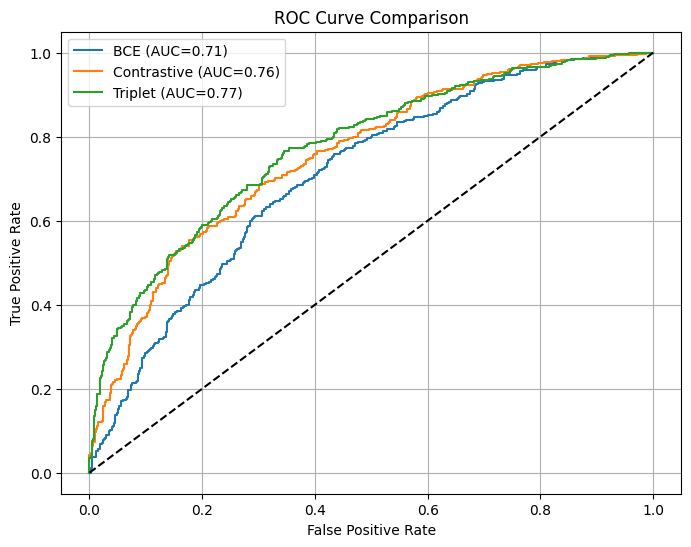

In [25]:
fpr_bce, tpr_bce, _ = roc_curve(y_test, bce_preds)
fpr_con, tpr_con, _ = roc_curve(y_test, 1 - norm_contrastive)
fpr_tri, tpr_tri, _ = roc_curve(y_test, 1 - norm_triplet)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bce, tpr_bce, label=f"BCE (AUC={auc_bce:.2f})")
plt.plot(fpr_con, tpr_con, label=f"Contrastive (AUC={auc_contrastive:.2f})")
plt.plot(fpr_tri, tpr_tri, label=f"Triplet (AUC={auc_triplet:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


#### Summary Table

In [26]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["BCE", "Contrastive", "Triplet"],
    "Accuracy": [acc_bce, acc_contrastive, acc_triplet],
    "AUC": [auc_bce, auc_contrastive, auc_triplet]
})

print(results_df)


         Model  Accuracy       AUC
0          BCE     0.595  0.708956
1  Contrastive     0.613  0.755180
2      Triplet     0.515  0.774012


### comparing effect of Binary Cross-Entropy (BCE) loss and Mean Squared Error (MSE) as a reconstruction loss during training of a Variational Autoencoder (VAE).


#### Define the VAE model (shared architecture)

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

latent_dim = 2

# Encoder
class Encoder(Model):
    def __init__(self):
        super().__init__()
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(256, activation='relu')
        self.mu = layers.Dense(latent_dim)
        self.log_var = layers.Dense(latent_dim)

    def call(self, x):
        x = self.flatten(x)
        x = self.dense1(x)
        mu = self.mu(x)
        log_var = self.log_var(x)
        return mu, log_var

# Reparameterization
def sample_z(mu, log_var):
    eps = tf.random.normal(shape=tf.shape(mu))
    return mu + tf.exp(0.5 * log_var) * eps

# Decoder
class Decoder(Model):
    def __init__(self):
        super().__init__()
        self.dense1 = layers.Dense(256, activation='relu')
        self.dense2 = layers.Dense(28 * 28, activation='sigmoid')
        self.reshape = layers.Reshape((28, 28, 1))

    def call(self, z):
        x = self.dense1(z)
        x = self.dense2(x)
        return self.reshape(x)


#### VAE with custom training

In [31]:
# VAE Model with custom training step
class VAE(Model):
    def __init__(self, encoder, decoder, loss_type='bce'):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.loss_type = loss_type
        # Define loss functions here to reuse
        self.bce_loss_fn = tf.keras.losses.BinaryCrossentropy()
        self.mse_loss_fn = tf.keras.losses.MeanSquaredError()
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            mu, log_var = self.encoder(data)
            z = sample_z(mu, log_var)
            reconstruction = self.decoder(z)

            if self.loss_type == 'bce':
                recon_loss = self.bce_loss_fn(data, reconstruction) * 28 * 28
            else:
                recon_loss = self.mse_loss_fn(data, reconstruction) * 28 * 28

            kl_loss = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


Training VAE with Binary Cross-Entropy loss
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - kl_loss: 11.8881 - loss: 247.8006 - recon_loss: 235.9125
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.3674 - loss: 170.8561 - recon_loss: 167.4887
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.1548 - loss: 165.6287 - recon_loss: 162.4739
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.1390 - loss: 163.4711 - recon_loss: 160.3321
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.1201 - loss: 161.9841 - recon_loss: 158.8640
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 3.1446 - loss: 160.6896 - recon_loss: 157.5450
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.1820 - loss: 159.3627 - recon_loss: 156.1808
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 3.2397 - loss: 158.0621 - recon_loss: 154.8224
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 3.2810 - los

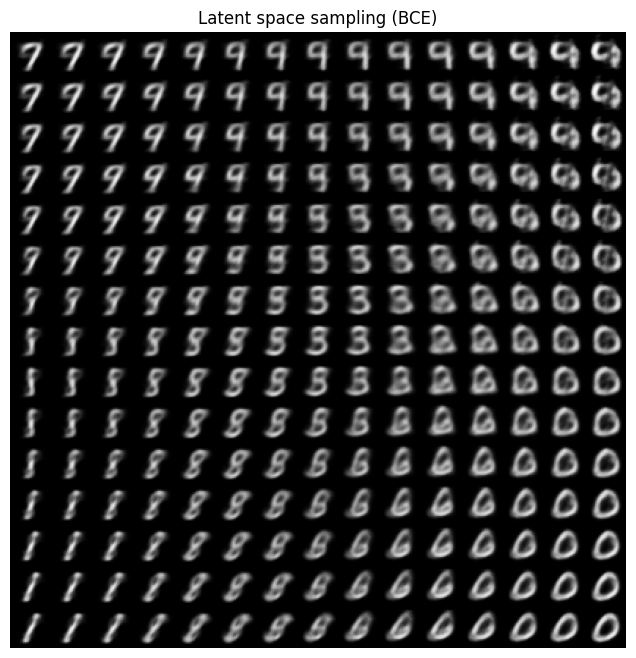

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

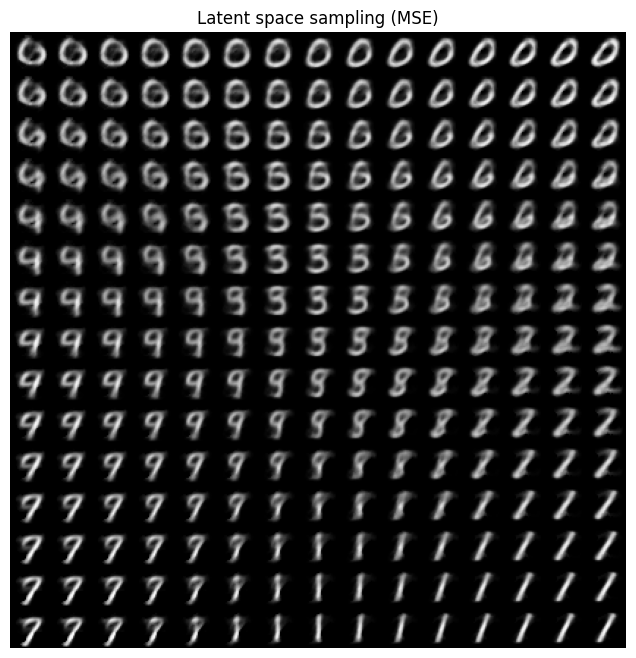

In [32]:
# Load and preprocess MNIST
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_train = np.expand_dims(x_train, -1)

batch_size = 128
train_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(1024).batch(batch_size)

# Create and train BCE VAE
encoder_bce = Encoder()
decoder_bce = Decoder()
vae_bce = VAE(encoder_bce, decoder_bce, loss_type='bce')
vae_bce.compile(optimizer=tf.keras.optimizers.Adam())

print("Training VAE with Binary Cross-Entropy loss")
vae_bce.fit(train_ds, epochs=10)

# Create and train MSE VAE
encoder_mse = Encoder()
decoder_mse = Decoder()
vae_mse = VAE(encoder_mse, decoder_mse, loss_type='mse')
vae_mse.compile(optimizer=tf.keras.optimizers.Adam())

print("Training VAE with Mean Squared Error loss")
vae_mse.fit(train_ds, epochs=10)

# Optional: function to visualize latent space sampling
import matplotlib.pyplot as plt

def plot_latent_space(decoder, n=15, digit_size=28):
    grid_x = np.linspace(-2, 2, n)
    grid_y = np.linspace(-2, 2, n)[::-1]

    canvas = np.zeros((digit_size * n, digit_size * n))
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = np.array([[xi, yi]])
            x_decoded = decoder.predict(z)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            canvas[i * digit_size:(i + 1) * digit_size,
                   j * digit_size:(j + 1) * digit_size] = digit

    plt.figure(figsize=(8, 8))
    plt.imshow(canvas, cmap='gray')
    plt.title(f"Latent space sampling ({'BCE' if decoder == decoder_bce else 'MSE'})")
    plt.axis('off')
    plt.show()

# Plot latent spaces
plot_latent_space(decoder_bce)
plot_latent_space(decoder_mse)

#### Add these callbacks and evaluation after training


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.5495 - loss: 147.1432 - recon_loss: 143.5937
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 3.5426 - loss: 146.9672 - recon_loss: 143.4246
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.5510 - loss: 146.8164 - recon_loss: 143.2654
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 3.5487 - loss: 146.7028 - recon_loss: 143.1541
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 3.5472 - loss: 146.5940 - recon_loss: 143.0468
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.5507 - loss: 146.5018 - recon_loss: 142.9511
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.5452 - loss: 146.4790 - recon_loss: 142.9339
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.5547 - loss: 146.3938 - recon_loss: 142.8391
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - kl_loss: 3.5519 - loss: 146.2717 - recon_loss: 142.7198
Epoch 10/1

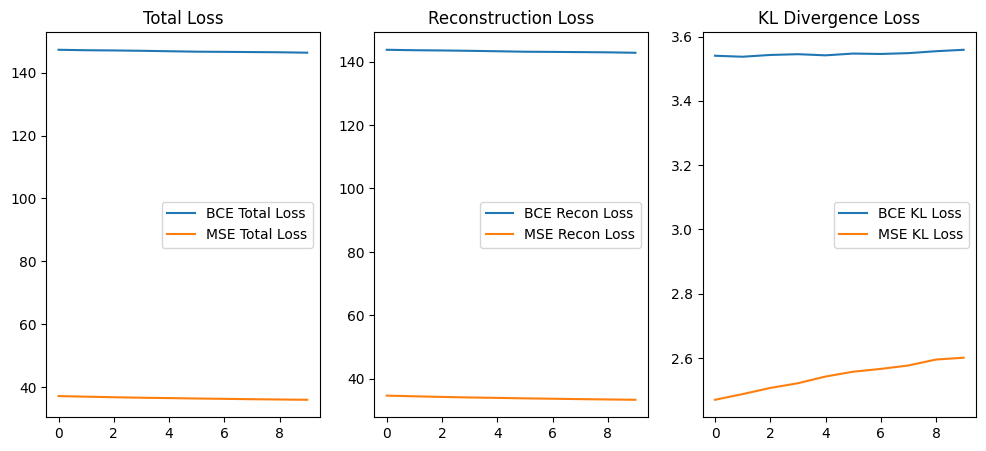

Reconstructions - BCE VAE


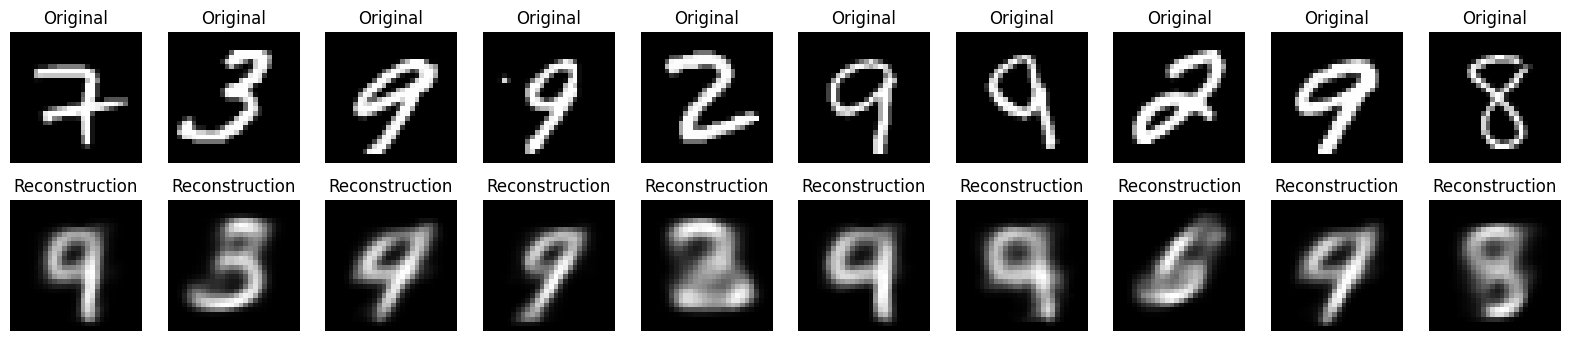

Reconstructions - MSE VAE


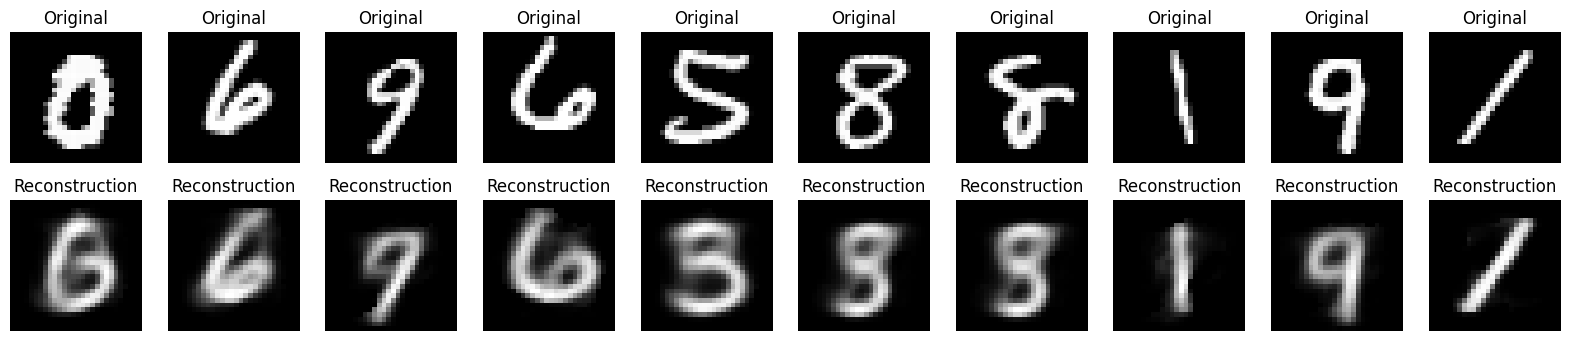

In [34]:
import matplotlib.pyplot as plt

# Train with history returned for both models
history_bce = vae_bce.fit(train_ds, epochs=10)
history_mse = vae_mse.fit(train_ds, epochs=10)

# Plot Loss curves
def plot_losses(hist_bce, hist_mse):
    plt.figure(figsize=(12,5))

    # Total loss
    plt.subplot(1,3,1)
    plt.plot(hist_bce.history['loss'], label='BCE Total Loss')
    plt.plot(hist_mse.history['loss'], label='MSE Total Loss')
    plt.title('Total Loss')
    plt.legend()

    # Reconstruction loss
    plt.subplot(1,3,2)
    plt.plot(hist_bce.history['recon_loss'], label='BCE Recon Loss')
    plt.plot(hist_mse.history['recon_loss'], label='MSE Recon Loss')
    plt.title('Reconstruction Loss')
    plt.legend()

    # KL divergence loss
    plt.subplot(1,3,3)
    plt.plot(hist_bce.history['kl_loss'], label='BCE KL Loss')
    plt.plot(hist_mse.history['kl_loss'], label='MSE KL Loss')
    plt.title('KL Divergence Loss')
    plt.legend()

    plt.show()

plot_losses(history_bce, history_mse)

# Visualize reconstructions on some test images
def show_reconstructions(model, data, n=10):
    samples = data.take(1).get_single_element().numpy()[:n]
    mu, log_var = model.encoder(samples)
    z = sample_z(mu, log_var)
    reconstructions = model.decoder(z).numpy()

    plt.figure(figsize=(20,4))
    for i in range(n):
        # Original
        plt.subplot(2, n, i + 1)
        plt.imshow(samples[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Reconstruction
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i].squeeze(), cmap='gray')
        plt.title("Reconstruction")
        plt.axis('off')
    plt.show()

print("Reconstructions - BCE VAE")
show_reconstructions(vae_bce, train_ds)

print("Reconstructions - MSE VAE")
show_reconstructions(vae_mse, train_ds)
